In [ ]:
import os
import sys
import json
import matplotlib.pyplot as plt
sys.path.append("../")

from src.data import NiiPoint
from src.processing import DataTfmLibrary as tfm_data, CONSTANTS

source_dir = f"../{CONSTANTS.DATA_PATH}"
target_dir = f"../{CONSTANTS.NORM_DATA_PATH}"
val_split = 0.2

## Data source
img_test_dir = os.path.join(source_dir, "imagesTs")
lab_test_dir = os.path.join(source_dir, "labelsTs")

img_train_dir = os.path.join(source_dir, "imagesTr")
lab_train_dir = os.path.join(source_dir, "labelsTr")

# Data target
target_img_test_dir = os.path.join(target_dir, "imagesTs")
target_lab_test_dir = os.path.join(target_dir, "labelsTs")

target_img_train_dir = os.path.join(target_dir, "imagesTr")
target_lab_train_dir = os.path.join(target_dir, "labelsTr")

target_img_val_dir = os.path.join(target_dir, "imagesVl")
target_lab_val_dir = os.path.join(target_dir, "labelsVl")

for dir_i in [
    target_img_test_dir,
    target_lab_test_dir,
    target_img_train_dir,
    target_lab_train_dir,
    target_img_val_dir,
    target_lab_val_dir,
]:
    os.makedirs(dir_i, exist_ok=True)
    

def process_data(img_path, lab_path, target_img_path, target_lab_path):
    ncct_data = NiiPoint.from_path(img_path, "cuda")
    cta_data = NiiPoint.from_path(lab_path, "cuda")

    ncct_norm = tfm_data.ncct_normalization_tfm(ncct_data)
    vess_norm = tfm_data.vessel_normalization_tfm(
        tfm_data.vessel_tfm(ncct_data, cta_data)
    )

    ncct_norm.save_to_path(target_img_path)
    vess_norm.save_to_path(target_lab_path)
    return ncct_norm, vess_norm


def cases_from_dir(images_dir):
    files = os.listdir(images_dir)
    cases = [file[:9] for file in files]
    return cases

if False:
    for file in cases_from_dir(img_test_dir):
        print(f"Processing {file}...", end="\r")
        process_data(
            os.path.join(img_test_dir, f"{file}_0000.nii.gz"),
            os.path.join(lab_test_dir, f"{file}_0001.nii.gz"),
            os.path.join(target_img_test_dir, f"{file}_0000.nii.gz"),
            os.path.join(target_lab_test_dir, f"{file}_0001.nii.gz"),
        )
        

    for i, file in enumerate(cases_from_dir(img_train_dir)):
        print(f"Processing {file}...", end="\r")
        if i < int(len(cases_from_dir(img_train_dir)) * (1 - val_split)):
            process_data(
                os.path.join(img_train_dir, f"{file}_0000.nii.gz"),
                os.path.join(lab_train_dir, f"{file}_0001.nii.gz"),
                os.path.join(target_img_train_dir, f"{file}_0000.nii.gz"),
                os.path.join(target_lab_train_dir, f"{file}_0001.nii.gz"),
            )
        else:
            process_data(
                os.path.join(img_train_dir, f"{file}_0000.nii.gz"),
                os.path.join(lab_train_dir, f"{file}_0001.nii.gz"),
                os.path.join(target_img_val_dir, f"{file}_0000.nii.gz"),
                os.path.join(target_lab_val_dir, f"{file}_0001.nii.gz"),
            )
            


    dataset_json = {
        "channel_names": {
            "0": "NCCT_norm",
            "1": "VSL_norm"
        },
        "numTraining": len(os.listdir(target_img_train_dir)),
        "numTest": len(os.listdir(target_img_test_dir)),
        "numValidation": len(os.listdir(target_img_val_dir)),
        "file_ending": ".nii.gz",
        "val_split": val_split,
    }

    with open(os.path.join(target_dir, "dataset.json"), "w") as f:
        json.dump(dataset_json, f, indent=4)

(np.float32(0.41015625), np.float32(0.41015625), np.float32(2.0))


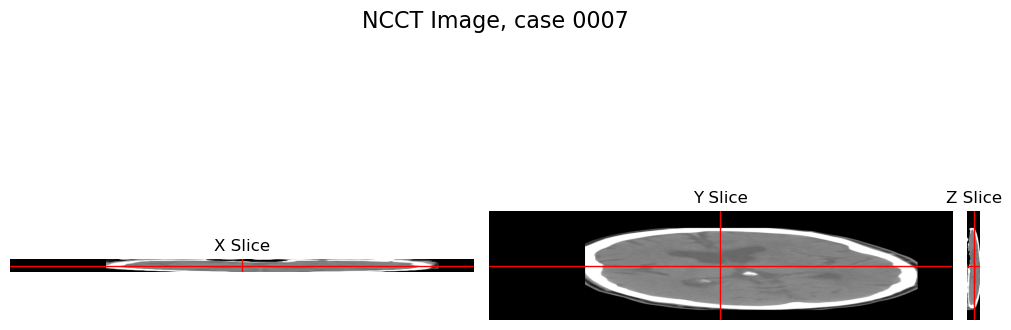

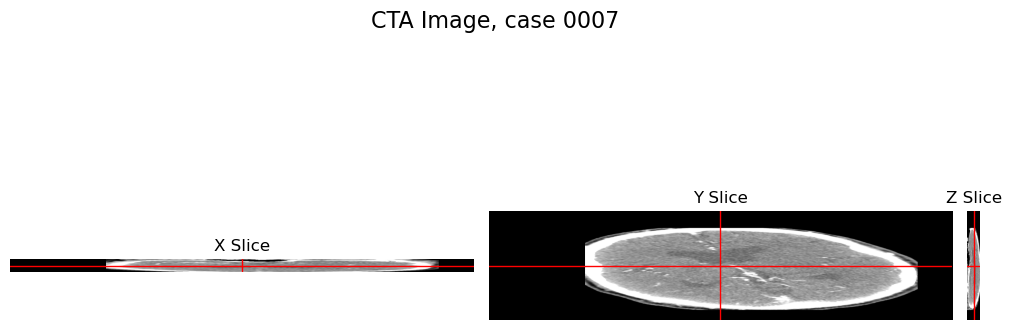

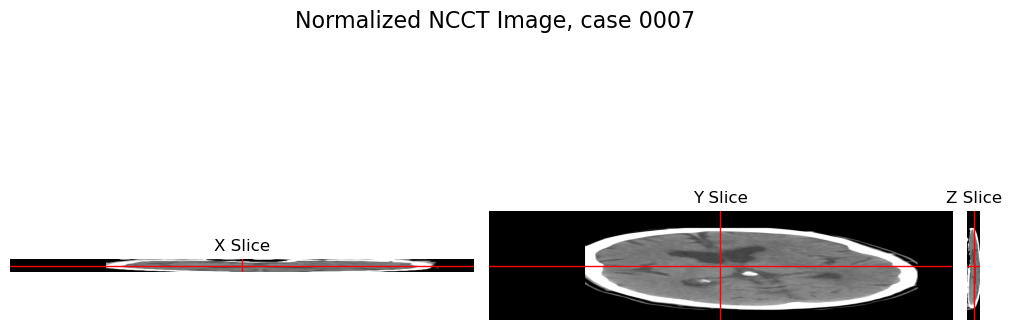

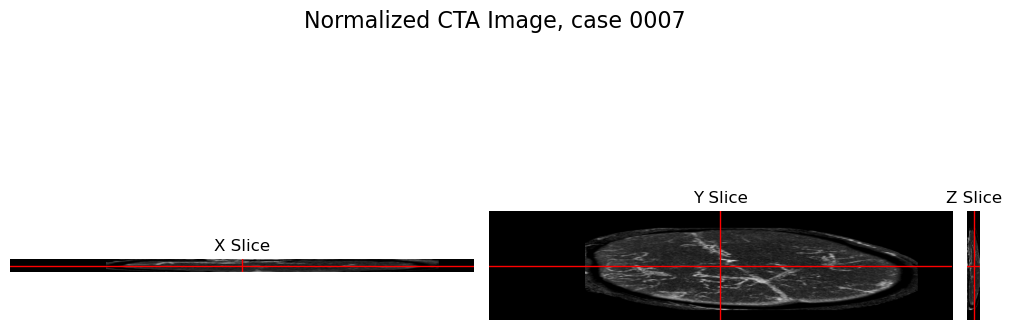

In [ ]:
case_id = 7
case_id_str = str(case_id).zfill(4)

x = NiiPoint.from_path(
    f"../{CONSTANTS.DATA_PATH}/imagesTr/case_{case_id_str}_0000.nii.gz",
    device="cpu",
    ensure_lps = True
    )
y = NiiPoint.from_path(
    f"../{CONSTANTS.DATA_PATH}/labelsTr/case_{case_id_str}_0001.nii.gz",
    device="cpu",
    ensure_lps = True
)

xtilde = NiiPoint.from_path(
    f"../{CONSTANTS.NORM_DATA_PATH_VAL_INP}/case_{case_id_str}_0000.nii.gz",
    device="cpu",
    ensure_lps = True
)

ytilde = NiiPoint.from_path(
    f"../{CONSTANTS.NORM_DATA_PATH_VAL_OUT}/case_{case_id_str}_0001.nii.gz",
    device="cpu",
    ensure_lps = True
)

print(ytilde.header.get_zooms())

slices = (0.5, 0.5, 0.5)
thicknesses = (1, 1, 1)
thicknesses_vess = (10, 10, 10)

x.plot_slices_nii(slices, thicknesses, cmap="gray", vmin=-100, vmax=150)
plt.suptitle(f"NCCT Image, case {case_id_str}", fontsize=16)
plt.tight_layout()
plt.gcf().savefig(f"../figures/data_NCCT.png", dpi=300)


y.plot_slices_nii(slices, thicknesses, cmap="gray", vmin=-100, vmax=150)
plt.suptitle(f"CTA Image, case {case_id_str}", fontsize=16)
plt.tight_layout()
plt.gcf().savefig(f"../figures/data_CTA.png", dpi=300)


xtilde.plot_slices_nii(slices, thicknesses, cmap="gray", vmin=-1, vmax=1)
plt.suptitle(f"Normalized NCCT Image, case {case_id_str}", fontsize=16)
plt.tight_layout()
plt.gcf().savefig(f"../figures/data_NCCT_norm.png", dpi=300)


ytilde.plot_slices_nii(slices, thicknesses_vess, cmap="gray", vmin=-1, vmax=0.2)
plt.suptitle(f"Normalized CTA Image, case {case_id_str}", fontsize=16)
plt.tight_layout()
plt.gcf().savefig(f"../figures/data_VES.png", dpi=300)
